# 03 การวิเคราะห์เชิงพรรณนาและเชิงวินิจฉัยของ LABAI

notebook นี้วิเคราะห์ข้อมูลระดับจังหวัดจากโครงการตัวกลางที่ดินของสถาบันบริหารจัดการธนาคารที่ดิน
ขอบเขตผลลัพธ์จำกัดอยู่ที่ไฟล์ 77 แถวที่ดาวน์โหลดใน Phase 2 และไม่สร้าง model

In [1]:
from pathlib import Path
import os
import tempfile

## ค้นหา root ของโครงการ

รองรับการเปิด notebook จาก `notebooks/` หรือจาก root ของโครงการ โดยตรวจหา `data/raw/` ที่มีอยู่จริง

In [2]:
def find_project_root():
    current_path = Path.cwd().resolve()
    candidate_paths = [current_path]
    candidate_paths.extend(current_path.parents)

    for candidate_path in candidate_paths:
        if (candidate_path / "data" / "raw").exists():
            return candidate_path

    raise FileNotFoundError("ไม่พบ root ของโครงการที่มี data/raw")


PROJECT_ROOT = find_project_root()

## ตั้งค่า runtime สำหรับกราฟ

กำหนด cache ชั่วคราวนอกโครงการและ backend แบบ non-interactive ก่อน import Matplotlib เพื่อไม่สร้างไฟล์ cache ใน public package

In [3]:
MPL_CONFIG_DIR = Path(tempfile.gettempdir()) / "dga306_matplotlib_cache"
MPL_CONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CONFIG_DIR))
os.environ.setdefault("MPLBACKEND", "Agg")

'module://matplotlib_inline.backend_inline'

## นำเข้าไลบรารีสำหรับข้อมูลและกราฟ

import Matplotlib หลังตั้งค่า runtime แล้ว และใช้ pandas สำหรับอ่านข้อมูลจริง

In [4]:
import matplotlib as mpl
mpl.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
from io import BytesIO
from IPython.display import Image, display

## ตั้งค่า font ภาษาไทย

กราฟใน notebook นี้มีข้อความภาษาไทย จึงใช้ Sarabun ที่มีอยู่ในโครงการเป็นตัวเลือกแรก
หากไม่พบไฟล์ font จะใช้ font มาตรฐานของระบบ และข้อความไทยอาจแสดงไม่สมบูรณ์

In [5]:
font_path = PROJECT_ROOT / "Sarabun-Regular.ttf"

if font_path.exists():
    mpl.font_manager.fontManager.addfont(str(font_path))
    plt.rcParams["font.family"] = "Sarabun"
else:
    plt.rcParams["font.family"] = "sans-serif"

plt.rcParams["axes.unicode_minus"] = False

## กำหนด path ของข้อมูลและ output

cell นี้กำหนดตำแหน่งไฟล์ข้อมูลดิบ, ข้อมูลที่ผ่าน cleaning และภาพประกอบรายงาน

In [6]:
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

DEMAND_SUPPLY_FILE = RAW_DATA_DIR / "labai_registered_land_demand_supply.json"
MATCHING_FILE = RAW_DATA_DIR / "labai_land_matching.xlsx"
LANDOWNERS_FILE = RAW_DATA_DIR / "labai_registered_landowners.json"

## ฟังก์ชันแสดงกราฟ

กราฟจะแสดงใน output ของ `.ipynb` โดยไม่บันทึกไฟล์ PNG เพิ่มใน public package

In [7]:
def show_figure(figure):
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=200, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    buffer.close()
    plt.close(figure)

## ระบุแหล่งข้อมูล

URL ต่อไปนี้เป็นหน้า metadata ทางการของไฟล์ที่ใช้ใน notebook นี้
ชื่อ variable อ้างอิงชื่อ column ที่ตรวจพบจริงจาก Phase 2 เท่านั้น

In [8]:
source_summary_df = pd.DataFrame(
    [
        {
            "dataset_name": "จำนวนข้อมูลผู้ประสงค์เข้าใช้ประโยชน์ในที่ดินและเจ้าของที่ดิน ที่ลงทะเบียน ของโครงการตัวกลางที่ดิน",
            "metadata_url": "https://data.go.th/dataset/65_dataset_11_03",
            "local_file": "data/raw/labai_registered_land_demand_supply.json",
            "format": "JSON",
        },
        {
            "dataset_name": "ข้อมูลการจับคู่ระหว่างผู้ประสงค์จะใช้ที่ดินกับเจ้าของที่ดินของโครงการตัวกลางที่ดิน",
            "metadata_url": "https://data.go.th/dataset/65_dataset_21_01",
            "local_file": "data/raw/labai_land_matching.xlsx",
            "format": "XLSX",
        },
        {
            "dataset_name": "จำนวนเจ้าของที่ดินที่ลงทะเบียนของโครงการตัวกลางที่ดิน",
            "metadata_url": "https://data.go.th/dataset/65_dataset_11_01",
            "local_file": "data/raw/labai_registered_landowners.json",
            "format": "JSON",
        },
    ]
)
source_summary_df

,dataset_name,metadata_url,local_file,format
0,จำนวนข้อมูลผู้ประสงค์เข้าใช้ประโยชน์ในที่ดินแล...,https://data.go.th/dataset/65_dataset_11_03,data/raw/labai_registered_land_demand_supply.json,JSON
1,ข้อมูลการจับคู่ระหว่างผู้ประสงค์จะใช้ที่ดินกับ...,https://data.go.th/dataset/65_dataset_21_01,data/raw/labai_land_matching.xlsx,XLSX
2,จำนวนเจ้าของที่ดินที่ลงทะเบียนของโครงการตัวกลา...,https://data.go.th/dataset/65_dataset_11_01,data/raw/labai_registered_landowners.json,JSON


## โหลดข้อมูล demand/supply

cell นี้อ่านไฟล์ JSON ที่มี column ระดับจังหวัดและจำนวนข้อมูลผู้ประสงค์กับเจ้าของที่ดิน

In [9]:
demand_supply_raw_df = pd.read_json(DEMAND_SUPPLY_FILE)
demand_supply_raw_df.head()

,PROVINCE_NAME,countw,count_want_land,area_rai_want_land,area_nga_want_land,area_wa_want_land,countowner,count_owner_land,area_rai_owner,area_nga_owner,area_wa_owner
0,กรุงเทพมหานคร,164,39,0,2,53.0,36,1,0,2,53.0
1,สมุทรปราการ,29,22,0,0,0.0,6,0,0,0,0.0
2,นนทบุรี,35,30,0,0,0.0,6,0,0,0,0.0
3,ปทุมธานี,44,72,1,0,0.0,2,1,1,0,0.0
4,พระนครศรีอยุธยา,15,19,0,0,0.0,3,0,0,0,0.0


## โหลดข้อมูลการจับคู่ที่ดิน

cell นี้อ่านไฟล์ XLSX ที่มี column `จังหวัด`, `จับคู่ได้`, `ผู้ประสงค์`, `เจ้าของที่ดิน` และ `แปลงที่ดิน`

In [10]:
matching_raw_df = pd.read_excel(MATCHING_FILE)
matching_raw_df.head()

,จังหวัด,จับคู่ได้,ผู้ประสงค์,เจ้าของที่ดิน,แปลงที่ดิน
0,กรุงเทพมหานคร,1,1,1,1
1,สมุทรปราการ,-,-,-,-
2,นนทบุรี,-,-,-,-
3,ปทุมธานี,1,1,1,1
4,พระนครศรีอยุธยา,-,-,-,-


## โหลดข้อมูลเจ้าของที่ดินลงทะเบียน

cell นี้อ่านไฟล์ JSON ที่มี column ระดับจังหวัดเกี่ยวกับเจ้าของและแปลงที่ดิน

In [11]:
landowners_raw_df = pd.read_json(LANDOWNERS_FILE)
landowners_raw_df.head()

,PROVINCE_NAME,countowner,count_owner_land,area_rai,area_nga,area_wa
0,กรุงเทพมหานคร,36,1,0,2,53.0
1,สมุทรปราการ,6,0,0,0,0.0
2,นนทบุรี,6,0,0,0,0.0
3,ปทุมธานี,2,1,1,0,0.0
4,พระนครศรีอยุธยา,3,0,0,0,0.0


## ตรวจขนาดและ schema ก่อน cleaning

ตารางนี้แสดงจำนวนแถว จำนวน column และรายชื่อ column จากไฟล์จริง

In [12]:
schema_review_df = pd.DataFrame(
    [
        {
            "dataset": "demand_supply",
            "row_count": demand_supply_raw_df.shape[0],
            "column_count": demand_supply_raw_df.shape[1],
            "columns_found": ", ".join(demand_supply_raw_df.columns.astype(str)),
        },
        {
            "dataset": "land_matching",
            "row_count": matching_raw_df.shape[0],
            "column_count": matching_raw_df.shape[1],
            "columns_found": ", ".join(matching_raw_df.columns.astype(str)),
        },
        {
            "dataset": "landowners",
            "row_count": landowners_raw_df.shape[0],
            "column_count": landowners_raw_df.shape[1],
            "columns_found": ", ".join(landowners_raw_df.columns.astype(str)),
        },
    ]
)
schema_review_df

,dataset,row_count,column_count,columns_found
0,demand_supply,77,11,"PROVINCE_NAME, countw, count_want_land, area_r..."
1,land_matching,77,5,"จังหวัด, จับคู่ได้, ผู้ประสงค์, เจ้าของที่ดิน,..."
2,landowners,77,6,"PROVINCE_NAME, countowner, count_owner_land, a..."


## กำหนด column สำหรับการวิเคราะห์

ชื่อเหล่านี้เป็นชื่อที่ตรวจพบจริงจากไฟล์ demand/supply และไฟล์การจับคู่
คำว่า demand และ supply ใน notebook ใช้เพื่ออ้างถึงชื่อ dataset และชื่อ column เท่านั้น ไม่ใช่การยืนยันนิยามเชิงนโยบายเพิ่มเติม

In [13]:
PROVINCE_COLUMN = "province_name"
WANT_COUNT_COLUMN = "count_want_land"
OWNER_LAND_COUNT_COLUMN = "count_owner_land"
MATCHED_COUNT_COLUMN = "จับคู่ได้"
APPLICANT_COUNT_COLUMN = "ผู้ประสงค์"
MATCHING_OWNER_COUNT_COLUMN = "เจ้าของที่ดิน"
LAND_PLOT_COUNT_COLUMN = "แปลงที่ดิน"

## สร้างชื่อจังหวัดมาตรฐานสำหรับการเชื่อมข้อมูล

การทำความสะอาดนี้ตัดช่องว่างต้นและท้ายของชื่อจังหวัดเท่านั้น และเก็บ column ต้นฉบับไว้

In [14]:
def normalize_province_name(series):
    return series.astype("string").str.strip()

## แปลงข้อความที่เป็นตัวเลขโดยไม่แทน placeholder

ฟังก์ชันนี้ลบ comma และตัดช่องว่าง จากนั้นแปลงค่าที่เป็น `-` หรือข้อความว่างเป็น missing value
ไม่ได้แทน `-` ด้วยศูนย์ เพราะ metadata ที่มีอยู่ไม่ยืนยันความหมายของสัญลักษณ์นี้

In [15]:
def convert_numeric_text_without_imputation(series):
    normalized_series = series.astype("string").str.replace(",", "", regex=False).str.strip()
    placeholder_mask = normalized_series.isin(["", "-"])
    normalized_series = normalized_series.mask(placeholder_mask, pd.NA)
    numeric_series = pd.to_numeric(normalized_series, errors="coerce")
    return numeric_series, placeholder_mask

## ทำความสะอาดข้อมูล demand/supply

เพิ่ม `province_name` เพื่อใช้เชื่อมข้อมูล เพิ่ม column ลงท้าย `_numeric` สำหรับ area fields และสร้างส่วนต่างของ count สอง column
ส่วนต่างนี้เป็น `count_want_land - count_owner_land` ตามชื่อ column เท่านั้น

In [16]:
demand_supply_cleaned_df = demand_supply_raw_df.copy()
demand_supply_cleaned_df[PROVINCE_COLUMN] = normalize_province_name(
    demand_supply_cleaned_df["PROVINCE_NAME"]
)

demand_supply_text_numeric_columns = [
    "area_rai_want_land",
    "area_nga_want_land",
    "area_rai_owner",
    "area_nga_owner",
]

for column_name in demand_supply_text_numeric_columns:
    numeric_values, placeholder_values = convert_numeric_text_without_imputation(
        demand_supply_cleaned_df[column_name]
    )
    demand_supply_cleaned_df[f"{column_name}_numeric"] = numeric_values
    demand_supply_cleaned_df[f"{column_name}_has_placeholder"] = placeholder_values

demand_supply_cleaned_df["count_gap_want_minus_owner"] = (
    demand_supply_cleaned_df[WANT_COUNT_COLUMN]
    - demand_supply_cleaned_df[OWNER_LAND_COUNT_COLUMN]
)

## ทำความสะอาดข้อมูลการจับคู่

เก็บค่า raw ไว้ เพิ่ม column `_numeric` สำหรับค่าที่แปลงได้ และเพิ่ม flag ของ placeholder
แถวที่มี `-` จึงคงเป็น missing value ใน column เชิงตัวเลข ไม่ถูกนับเป็นศูนย์

In [17]:
matching_cleaned_df = matching_raw_df.copy()
matching_cleaned_df[PROVINCE_COLUMN] = normalize_province_name(matching_cleaned_df["จังหวัด"])

matching_numeric_source_columns = [
    MATCHED_COUNT_COLUMN,
    APPLICANT_COUNT_COLUMN,
    MATCHING_OWNER_COUNT_COLUMN,
    LAND_PLOT_COUNT_COLUMN,
]

for column_name in matching_numeric_source_columns:
    numeric_values, placeholder_values = convert_numeric_text_without_imputation(
        matching_cleaned_df[column_name]
    )
    matching_cleaned_df[f"{column_name}_numeric"] = numeric_values
    matching_cleaned_df[f"{column_name}_has_placeholder"] = placeholder_values

## ทำความสะอาดข้อมูลเจ้าของที่ดินลงทะเบียน

เพิ่ม `province_name` และ column `_numeric` สำหรับ area fields โดยไม่คำนวณพื้นที่รวมข้ามหน่วย

In [18]:
landowners_cleaned_df = landowners_raw_df.copy()
landowners_cleaned_df[PROVINCE_COLUMN] = normalize_province_name(landowners_cleaned_df["PROVINCE_NAME"])

landowners_text_numeric_columns = ["area_rai", "area_nga"]

for column_name in landowners_text_numeric_columns:
    numeric_values, placeholder_values = convert_numeric_text_without_imputation(
        landowners_cleaned_df[column_name]
    )
    landowners_cleaned_df[f"{column_name}_numeric"] = numeric_values
    landowners_cleaned_df[f"{column_name}_has_placeholder"] = placeholder_values

## สรุปการตัดสินใจทำความสะอาด

ตารางนี้บันทึกการแปลงที่เกิดขึ้นจริง เพื่อให้ตรวจสอบย้อนกลับได้

In [19]:
cleaning_decisions_df = pd.DataFrame(
    [
        {
            "dataset": "demand_supply",
            "decision": "ตัดช่องว่างต้นและท้ายของชื่อจังหวัด",
            "result": "เพิ่ม province_name โดยเก็บ PROVINCE_NAME เดิมไว้",
        },
        {
            "dataset": "demand_supply",
            "decision": "แปลง area fields ที่เป็นข้อความ",
            "result": "เพิ่ม column _numeric และ _has_placeholder",
        },
        {
            "dataset": "land_matching",
            "decision": "เก็บ - เป็น missing value",
            "result": "เพิ่ม column _numeric และ _has_placeholder โดยไม่แทนค่าเป็นศูนย์",
        },
        {
            "dataset": "landowners",
            "decision": "แปลง area fields ที่เป็นข้อความ",
            "result": "เพิ่ม column _numeric และ _has_placeholder",
        },
    ]
)
cleaning_decisions_df

,dataset,decision,result
0,demand_supply,ตัดช่องว่างต้นและท้ายของชื่อจังหวัด,เพิ่ม province_name โดยเก็บ PROVINCE_NAME เดิมไว้
1,demand_supply,แปลง area fields ที่เป็นข้อความ,เพิ่ม column _numeric และ _has_placeholder
2,land_matching,เก็บ - เป็น missing value,เพิ่ม column _numeric และ _has_placeholder โดย...
3,landowners,แปลง area fields ที่เป็นข้อความ,เพิ่ม column _numeric และ _has_placeholder


## ตรวจ missing value และ placeholder หลัง cleaning

ตารางนี้แยก missing value ตามไฟล์ออกจาก placeholder `-` ที่ตรวจพบในข้อมูลการจับคู่

In [20]:
quality_summary_df = pd.DataFrame(
    [
        {
            "dataset": "demand_supply",
            "row_count": demand_supply_cleaned_df.shape[0],
            "missing_cell_count": int(demand_supply_cleaned_df.isna().sum().sum()),
            "placeholder_count": int(
                demand_supply_cleaned_df.filter(like="_has_placeholder").sum().sum()
            ),
            "duplicate_row_count": int(demand_supply_cleaned_df.duplicated().sum()),
        },
        {
            "dataset": "land_matching",
            "row_count": matching_cleaned_df.shape[0],
            "missing_cell_count": int(matching_cleaned_df.isna().sum().sum()),
            "placeholder_count": int(
                matching_cleaned_df.filter(like="_has_placeholder").sum().sum()
            ),
            "duplicate_row_count": int(matching_cleaned_df.duplicated().sum()),
        },
        {
            "dataset": "landowners",
            "row_count": landowners_cleaned_df.shape[0],
            "missing_cell_count": int(landowners_cleaned_df.isna().sum().sum()),
            "placeholder_count": int(
                landowners_cleaned_df.filter(like="_has_placeholder").sum().sum()
            ),
            "duplicate_row_count": int(landowners_cleaned_df.duplicated().sum()),
        },
    ]
)
quality_summary_df

,dataset,row_count,missing_cell_count,placeholder_count,duplicate_row_count
0,demand_supply,77,0,0,0
1,land_matching,77,280,280,0
2,landowners,77,0,0,0


## บันทึกข้อมูลที่ผ่าน cleaning

ไฟล์ CSV ใช้ UTF-8 with BOM เพื่อให้เปิดข้อความภาษาไทยได้สะดวกในโปรแกรมตารางข้อมูลทั่วไป

In [21]:
demand_supply_cleaned_df.to_csv(
    PROCESSED_DATA_DIR / "labai_demand_supply_cleaned.csv",
    index=False,
    encoding="utf-8-sig",
)
matching_cleaned_df.to_csv(
    PROCESSED_DATA_DIR / "labai_land_matching_cleaned.csv",
    index=False,
    encoding="utf-8-sig",
)
landowners_cleaned_df.to_csv(
    PROCESSED_DATA_DIR / "labai_landowners_cleaned.csv",
    index=False,
    encoding="utf-8-sig",
)

## สร้างตารางระดับจังหวัดสำหรับ demand/supply

ตารางนี้ใช้ `count_want_land`, `count_owner_land` และส่วนต่างที่คำนวณจากสอง column ดังกล่าว
ชื่อ column ต้นฉบับยังคงอยู่ในไฟล์ cleaned เพื่อให้ตรวจย้อนกลับได้

In [22]:
province_demand_supply_df = demand_supply_cleaned_df[
    [
        PROVINCE_COLUMN,
        "countw",
        WANT_COUNT_COLUMN,
        "countowner",
        OWNER_LAND_COUNT_COLUMN,
        "count_gap_want_minus_owner",
    ]
].sort_values("count_gap_want_minus_owner", ascending=False)
province_demand_supply_df.head(10)

,province_name,countw,count_want_land,countowner,count_owner_land,count_gap_want_minus_owner
38,ลำพูน,308,310,0,2,308
44,เชียงราย,158,166,0,28,138
18,นครราชสีมา,74,101,3,0,101
3,ปทุมธานี,44,72,2,1,71
37,เชียงใหม่,49,54,15,3,51
49,ตาก,43,45,1,1,44
0,กรุงเทพมหานคร,164,39,36,1,38
57,นครปฐม,26,41,2,4,37
10,ชลบุรี,36,35,5,1,34
2,นนทบุรี,35,30,6,0,30


## สรุป descriptive statistics ของ count fields

ตารางนี้ตอบคำถามว่าค่าของ count fields ใน 77 แถวมีการกระจายอย่างไร
ไม่ได้สรุปว่าเป็นค่าของประชากรทั้งประเทศหรือของทุกช่วงเวลา

In [23]:
demand_supply_describe_df = province_demand_supply_df[
    ["countw", WANT_COUNT_COLUMN, "countowner", OWNER_LAND_COUNT_COLUMN, "count_gap_want_minus_owner"]
].describe()
demand_supply_describe_df

,countw,count_want_land,countowner,count_owner_land,count_gap_want_minus_owner
count,77.000000,77.000000,77.000000,77.000000,77.000000
mean,16.831169,17.805195,1.740260,1.038961,16.766234
std,43.462750,41.759348,4.499715,3.416067,40.281214
min,0.000000,0.000000,0.000000,0.000000,-4.000000
25%,2.000000,2.000000,0.000000,0.000000,2.000000
50%,4.000000,5.000000,1.000000,0.000000,5.000000
75%,11.000000,17.000000,2.000000,1.000000,15.000000
max,308.000000,310.000000,36.000000,28.000000,308.000000


## เตรียมอันดับจังหวัดตาม count_want_land

ใช้ 15 จังหวัดแรกตามค่าจาก `count_want_land` เพื่อให้ป้ายชื่ออ่านได้ชัดเจน

In [24]:
top_demand_df = province_demand_supply_df.nlargest(15, WANT_COUNT_COLUMN).sort_values(
    WANT_COUNT_COLUMN
)
top_demand_df

,province_name,countw,count_want_land,countowner,count_owner_land,count_gap_want_minus_owner
11,ระยอง,16,21,2,2,19
1,สมุทรปราการ,29,22,6,0,22
14,ฉะเชิงเทรา,15,26,3,1,25
16,นครนายก,3,28,0,4,24
2,นนทบุรี,35,30,6,0,30
10,ชลบุรี,36,35,5,1,34
54,ราชบุรี,13,37,2,8,29
0,กรุงเทพมหานคร,164,39,36,1,38
57,นครปฐม,26,41,2,4,37
49,ตาก,43,45,1,1,44


## กราฟอันดับจังหวัดตาม count_want_land

แหล่งข้อมูลคือ JSON demand/supply ใช้ `province_name` และ `count_want_land` หลังตัดช่องว่างชื่อจังหวัด
กราฟตอบคำถามว่าจังหวัดใดมีค่าสูงสุดใน column นี้ของไฟล์ที่ดาวน์โหลดมา
การตีความต้องอิงชื่อ column และ metadata ที่มีอยู่ ไม่ควรขยายผลเป็นความต้องการที่ดินทั้งหมดของประเทศ

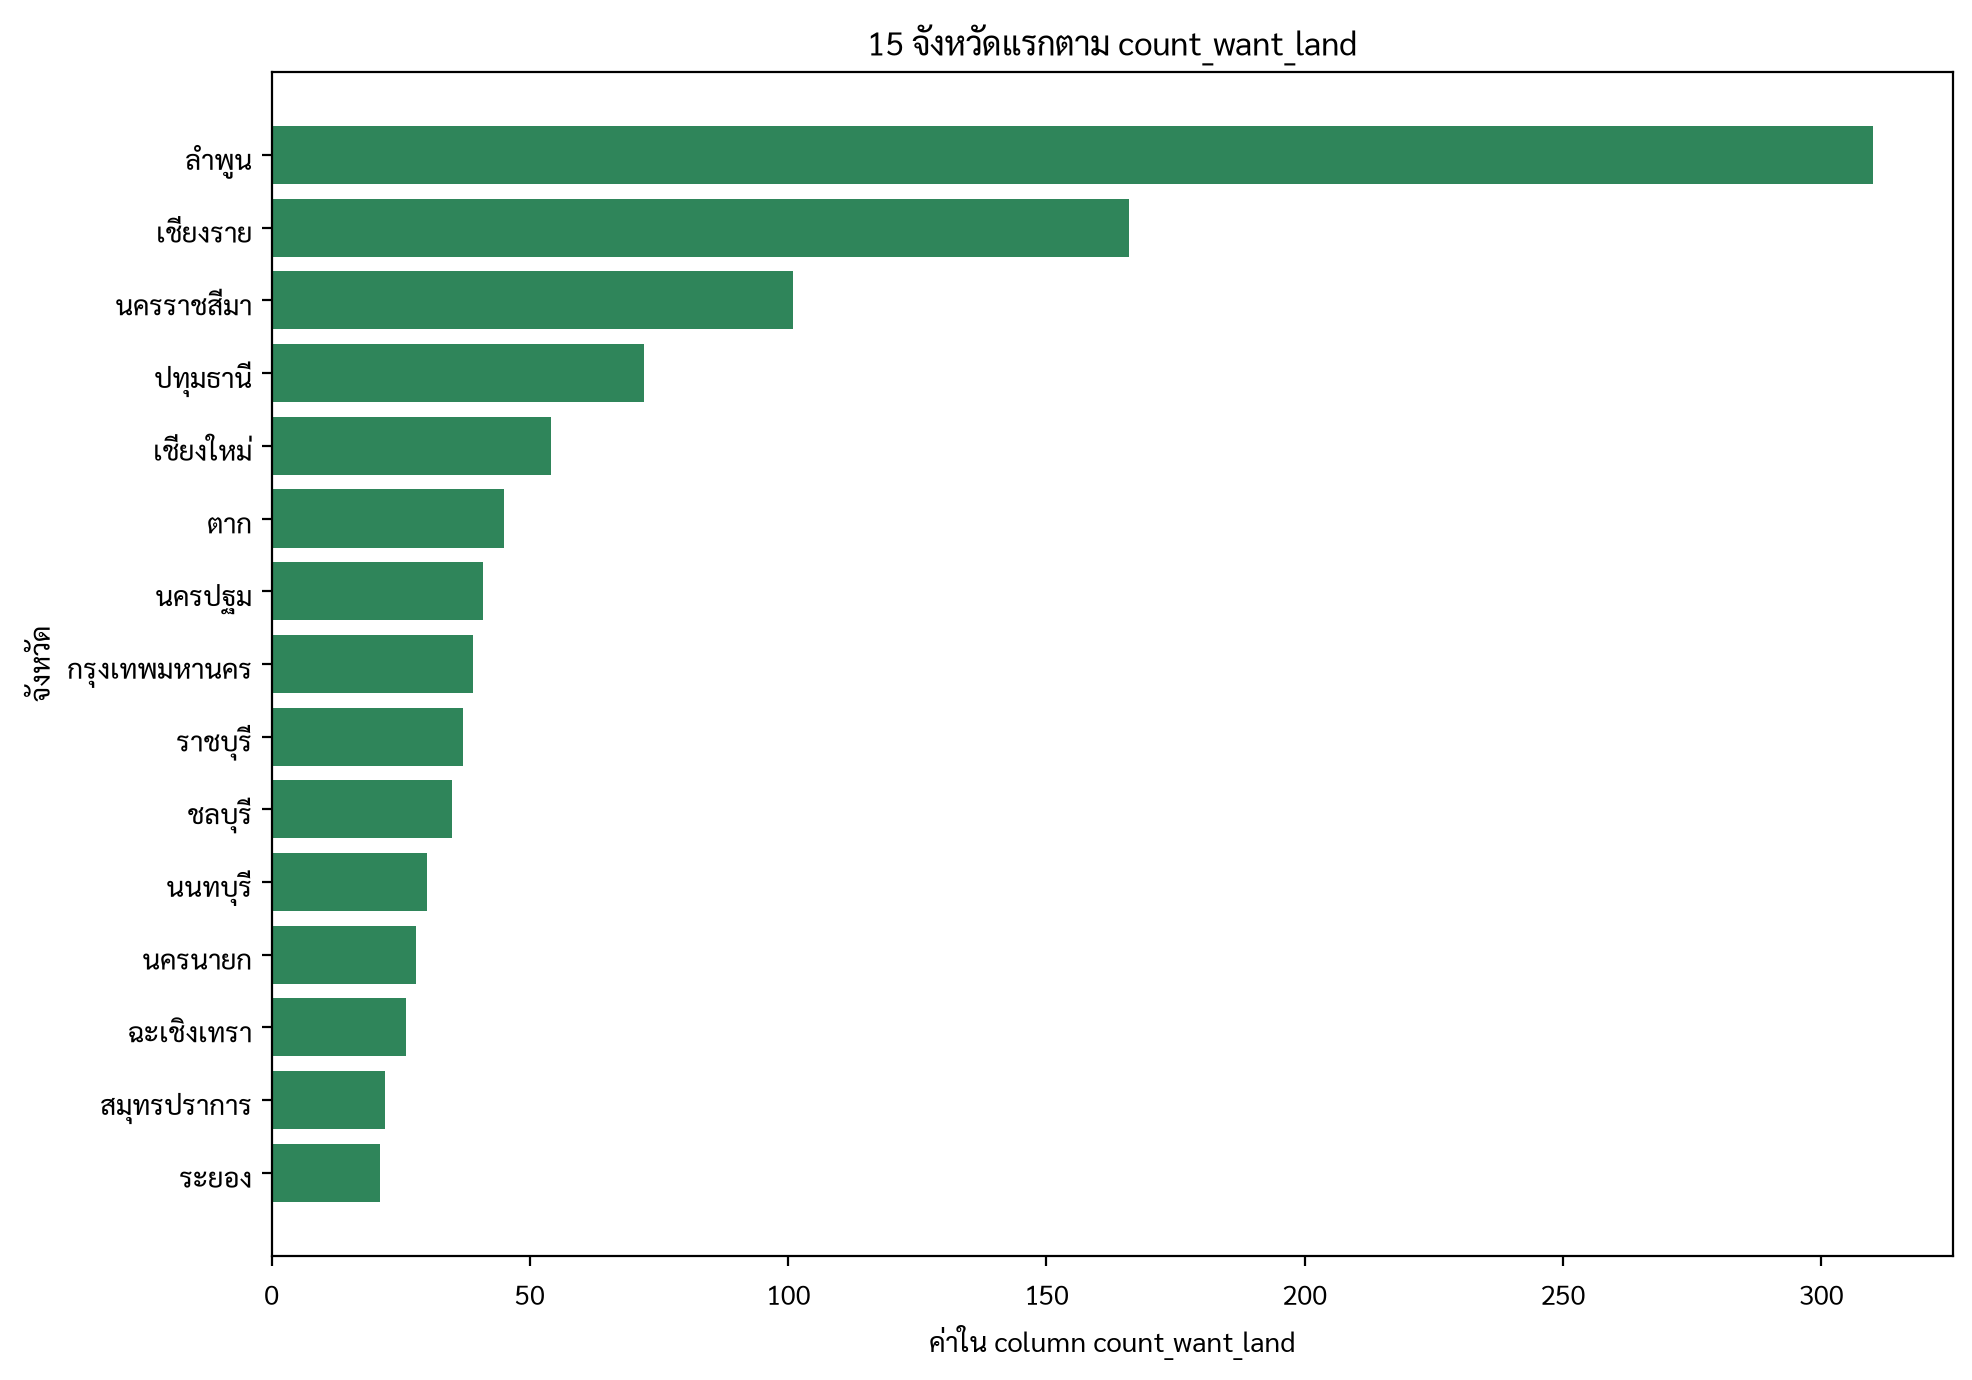

In [25]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_demand_df[PROVINCE_COLUMN], top_demand_df[WANT_COUNT_COLUMN], color="#2f855a")
ax.set_title("15 จังหวัดแรกตาม count_want_land")
ax.set_xlabel("ค่าใน column count_want_land")
ax.set_ylabel("จังหวัด")
fig.tight_layout()
show_figure(fig)

## เตรียมอันดับจังหวัดตาม count_owner_land

ใช้ 15 จังหวัดแรกตามค่าจาก `count_owner_land` ของไฟล์เดียวกัน

In [26]:
top_supply_df = province_demand_supply_df.nlargest(15, OWNER_LAND_COUNT_COLUMN).sort_values(
    OWNER_LAND_COUNT_COLUMN
)
top_supply_df

,province_name,countw,count_want_land,countowner,count_owner_land,count_gap_want_minus_owner
0,กรุงเทพมหานคร,164,39,36,1,38
3,ปทุมธานี,44,72,2,1,71
49,ตาก,43,45,1,1,44
38,ลำพูน,308,310,0,2,308
56,สุพรรณบุรี,12,17,1,2,15
11,ระยอง,16,21,2,2,19
37,เชียงใหม่,49,54,15,3,51
33,กาฬสินธุ์,2,1,1,3,-2
57,นครปฐม,26,41,2,4,37
27,ขอนแก่น,13,21,6,4,17


## กราฟอันดับจังหวัดตาม count_owner_land

แหล่งข้อมูลคือ JSON demand/supply ใช้ `province_name` และ `count_owner_land` หลังตัดช่องว่างชื่อจังหวัด
กราฟตอบคำถามว่าจังหวัดใดมีค่าสูงสุดใน column นี้ของไฟล์ที่ดาวน์โหลดมา
ค่านี้ไม่ควรถูกตีความเป็นจำนวนที่ดินทั้งหมดก่อนยืนยันนิยามจาก metadata

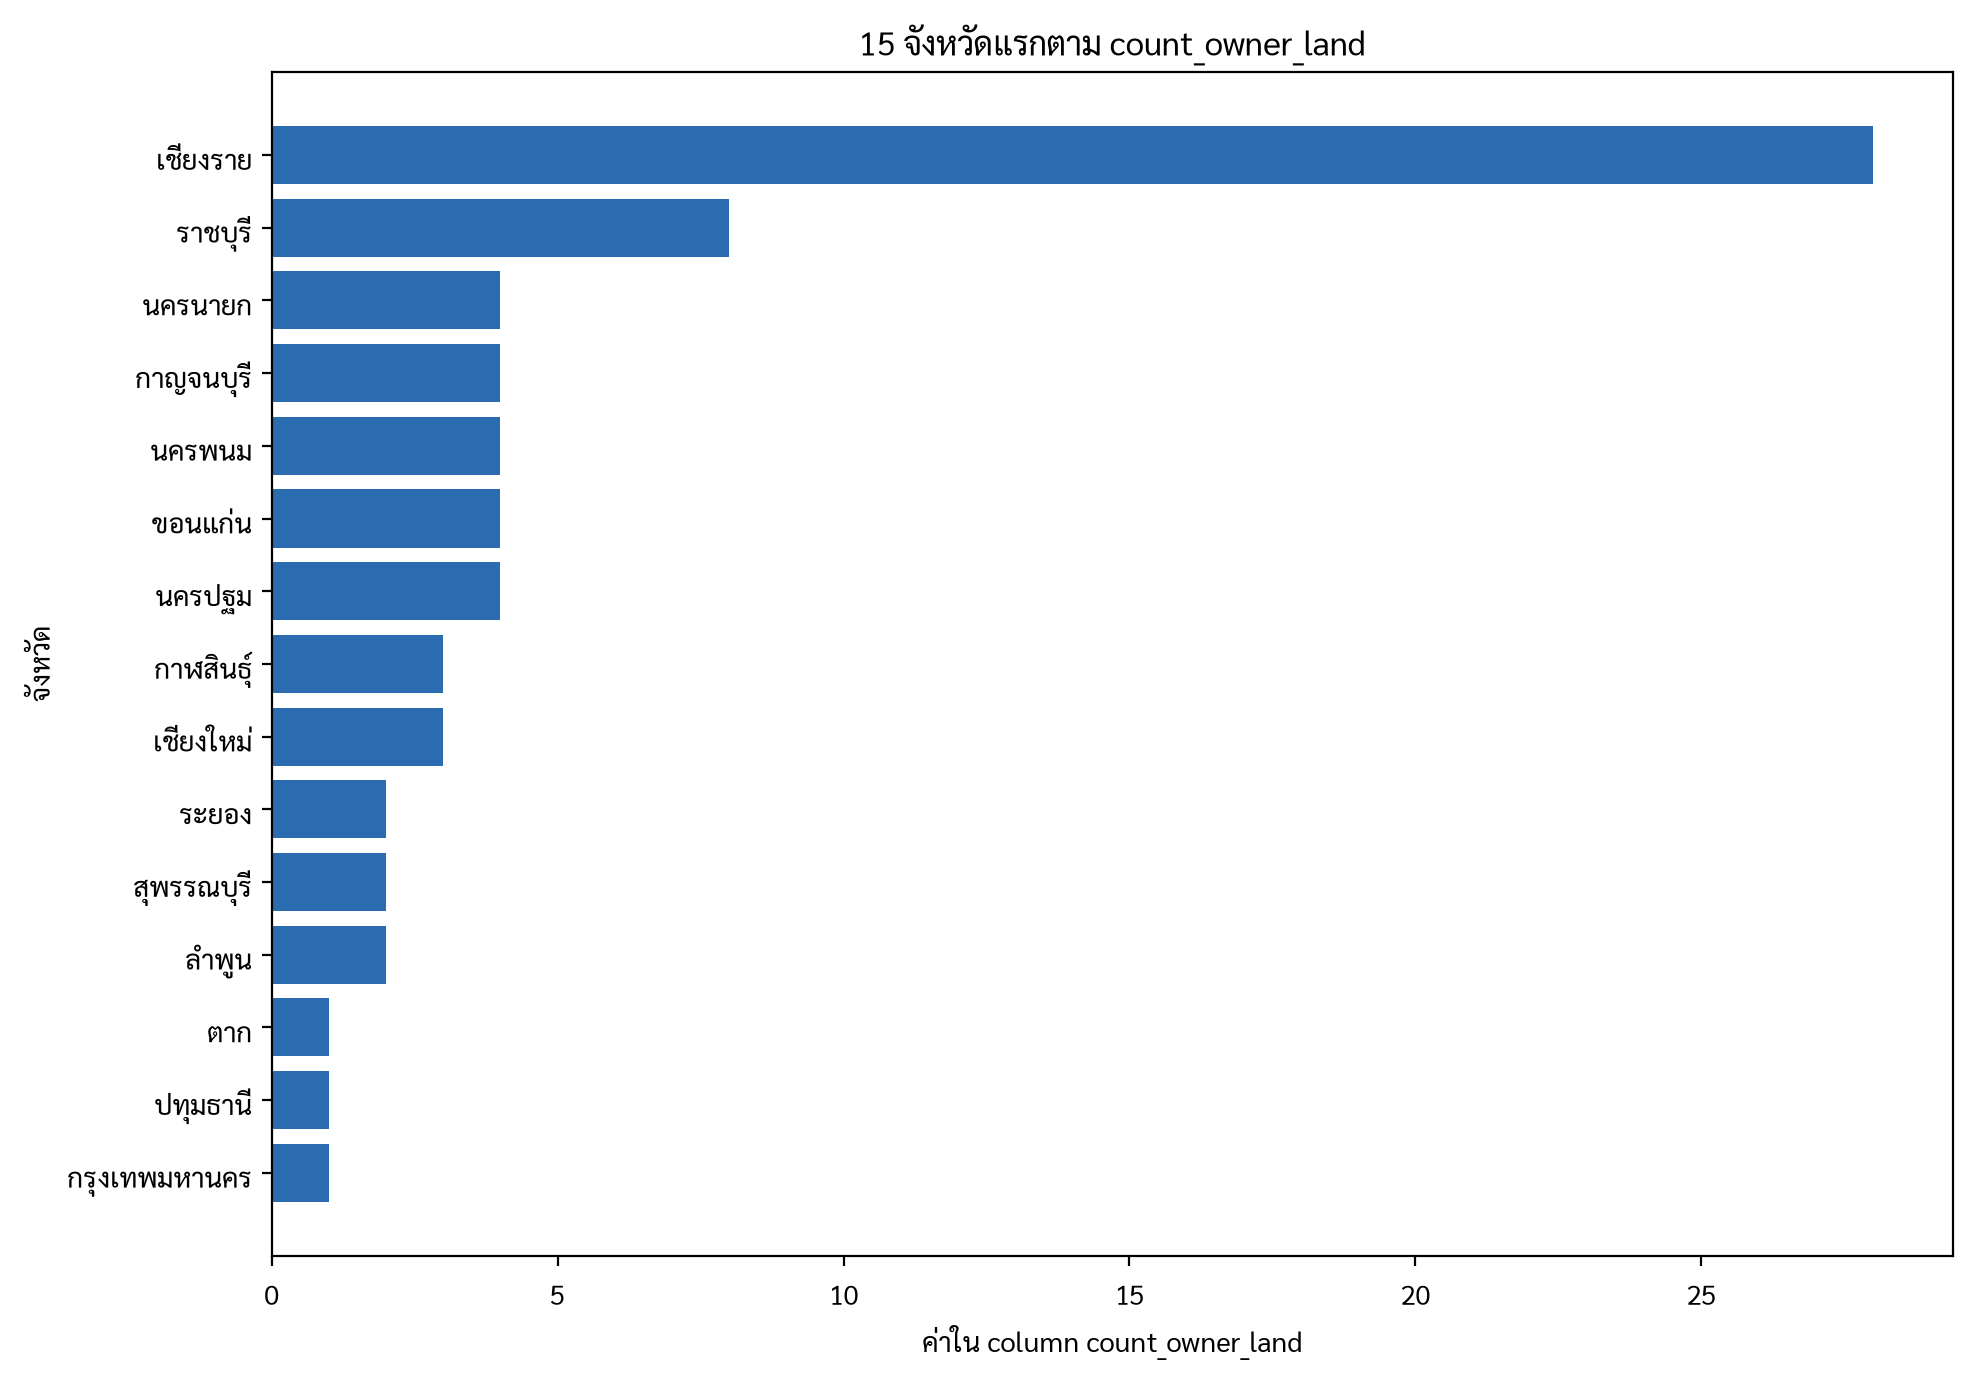

In [27]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_supply_df[PROVINCE_COLUMN], top_supply_df[OWNER_LAND_COUNT_COLUMN], color="#2b6cb0")
ax.set_title("15 จังหวัดแรกตาม count_owner_land")
ax.set_xlabel("ค่าใน column count_owner_land")
ax.set_ylabel("จังหวัด")
fig.tight_layout()
show_figure(fig)

## เตรียมอันดับส่วนต่างของ count fields

ค่า gap คำนวณจาก `count_want_land - count_owner_land` โดยไม่มีการปรับมาตราส่วนหรือแทนค่าที่หาย

In [28]:
top_gap_df = province_demand_supply_df.nlargest(15, "count_gap_want_minus_owner").sort_values(
    "count_gap_want_minus_owner"
)
top_gap_df

,province_name,countw,count_want_land,countowner,count_owner_land,count_gap_want_minus_owner
4,พระนครศรีอยุธยา,15,19,3,0,19
1,สมุทรปราการ,29,22,6,0,22
16,นครนายก,3,28,0,4,24
14,ฉะเชิงเทรา,15,26,3,1,25
54,ราชบุรี,13,37,2,8,29
2,นนทบุรี,35,30,6,0,30
10,ชลบุรี,36,35,5,1,34
57,นครปฐม,26,41,2,4,37
0,กรุงเทพมหานคร,164,39,36,1,38
49,ตาก,43,45,1,1,44


## กราฟส่วนต่างระหว่าง count_want_land และ count_owner_land

แหล่งข้อมูลคือ JSON demand/supply ใช้ส่วนต่างที่คำนวณจากสอง column ที่พบจริง
กราฟตอบคำถามว่าจังหวัดใดมีส่วนต่างบวกสูงในไฟล์ 77 แถวนี้
ส่วนต่างบวกไม่ได้พิสูจน์ว่าเกิดการขาดแคลนจริง จนกว่าจะยืนยันนิยามและช่วงเวลาของข้อมูล

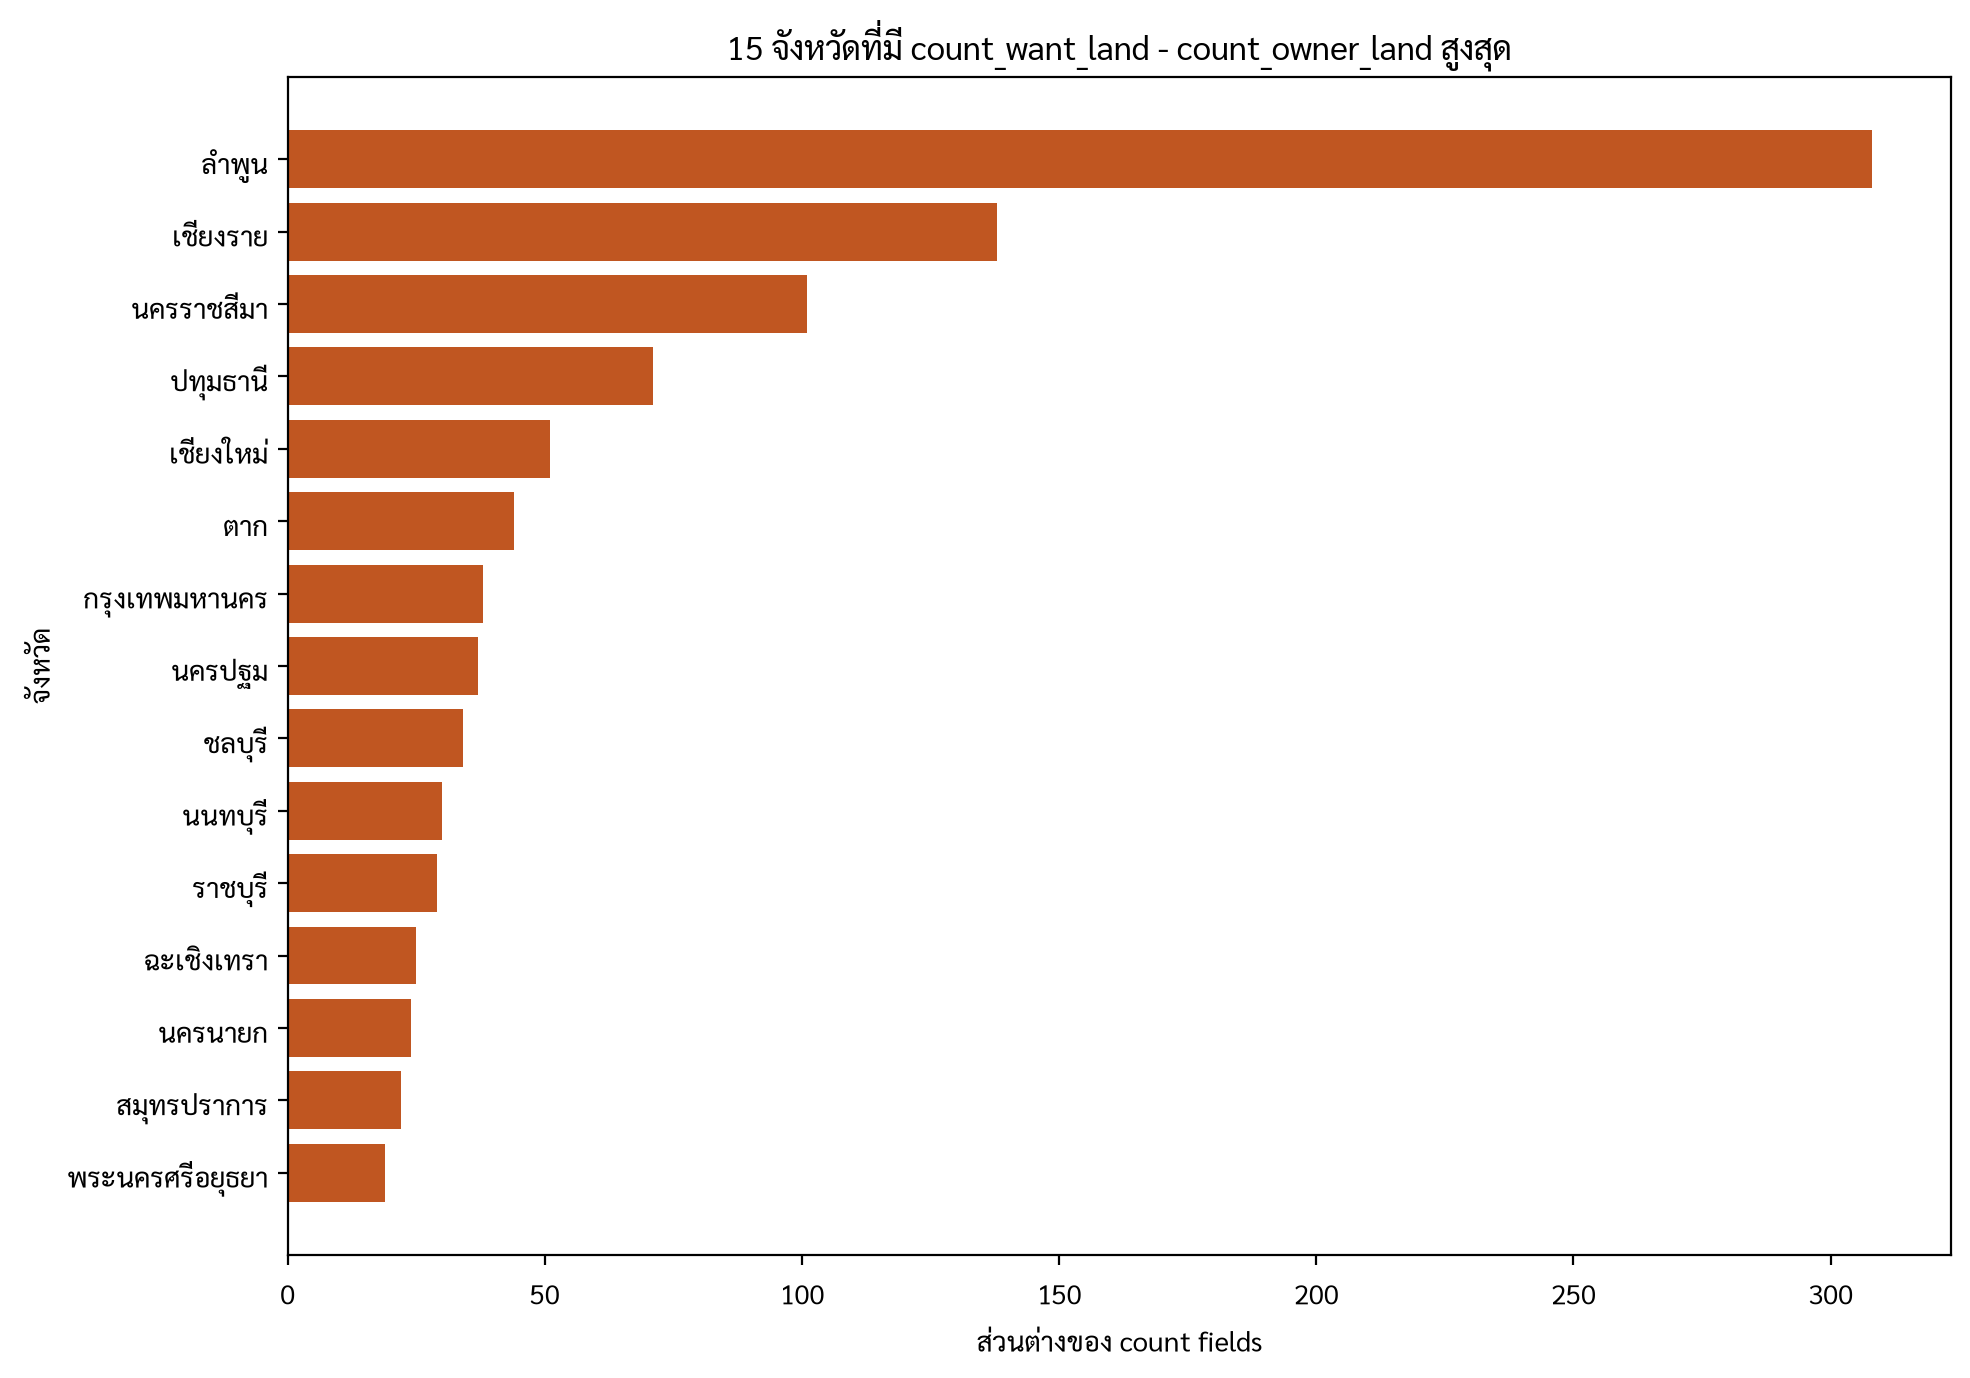

In [29]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_gap_df[PROVINCE_COLUMN], top_gap_df["count_gap_want_minus_owner"], color="#c05621")
ax.set_title("15 จังหวัดที่มี count_want_land - count_owner_land สูงสุด")
ax.set_xlabel("ส่วนต่างของ count fields")
ax.set_ylabel("จังหวัด")
fig.tight_layout()
show_figure(fig)

## คำนวณความสัมพันธ์ของ count fields

ค่า Pearson correlation ใช้เพื่อสำรวจความสัมพันธ์เชิงเส้นของสอง column ในไฟล์ที่ดาวน์โหลด
ไม่ได้ใช้ยืนยันเหตุและผล หรือสรุปถึงข้อมูลนอก 77 แถวนี้

In [30]:
demand_supply_correlation = province_demand_supply_df[WANT_COUNT_COLUMN].corr(
    province_demand_supply_df[OWNER_LAND_COUNT_COLUMN]
)
pd.DataFrame(
    [{"comparison": "count_want_land กับ count_owner_land", "pearson_correlation": demand_supply_correlation}]
)

,comparison,pearson_correlation
0,count_want_land กับ count_owner_land,0.465944


## กราฟกระจายระหว่าง count_want_land และ count_owner_land

แหล่งข้อมูลคือ JSON demand/supply ใช้สอง column เชิงจำนวนจาก 77 จังหวัด
กราฟตอบคำถามว่าค่าของสอง column กระจายร่วมกันอย่างไร และใช้ประกอบการอ่านค่า correlation
จุดที่อยู่ห่างจากกลุ่มควรถูกตรวจ metadata และคุณภาพข้อมูลเพิ่มเติม ไม่ควรสรุปว่าเป็นความผิดปกติเชิงนโยบายทันที

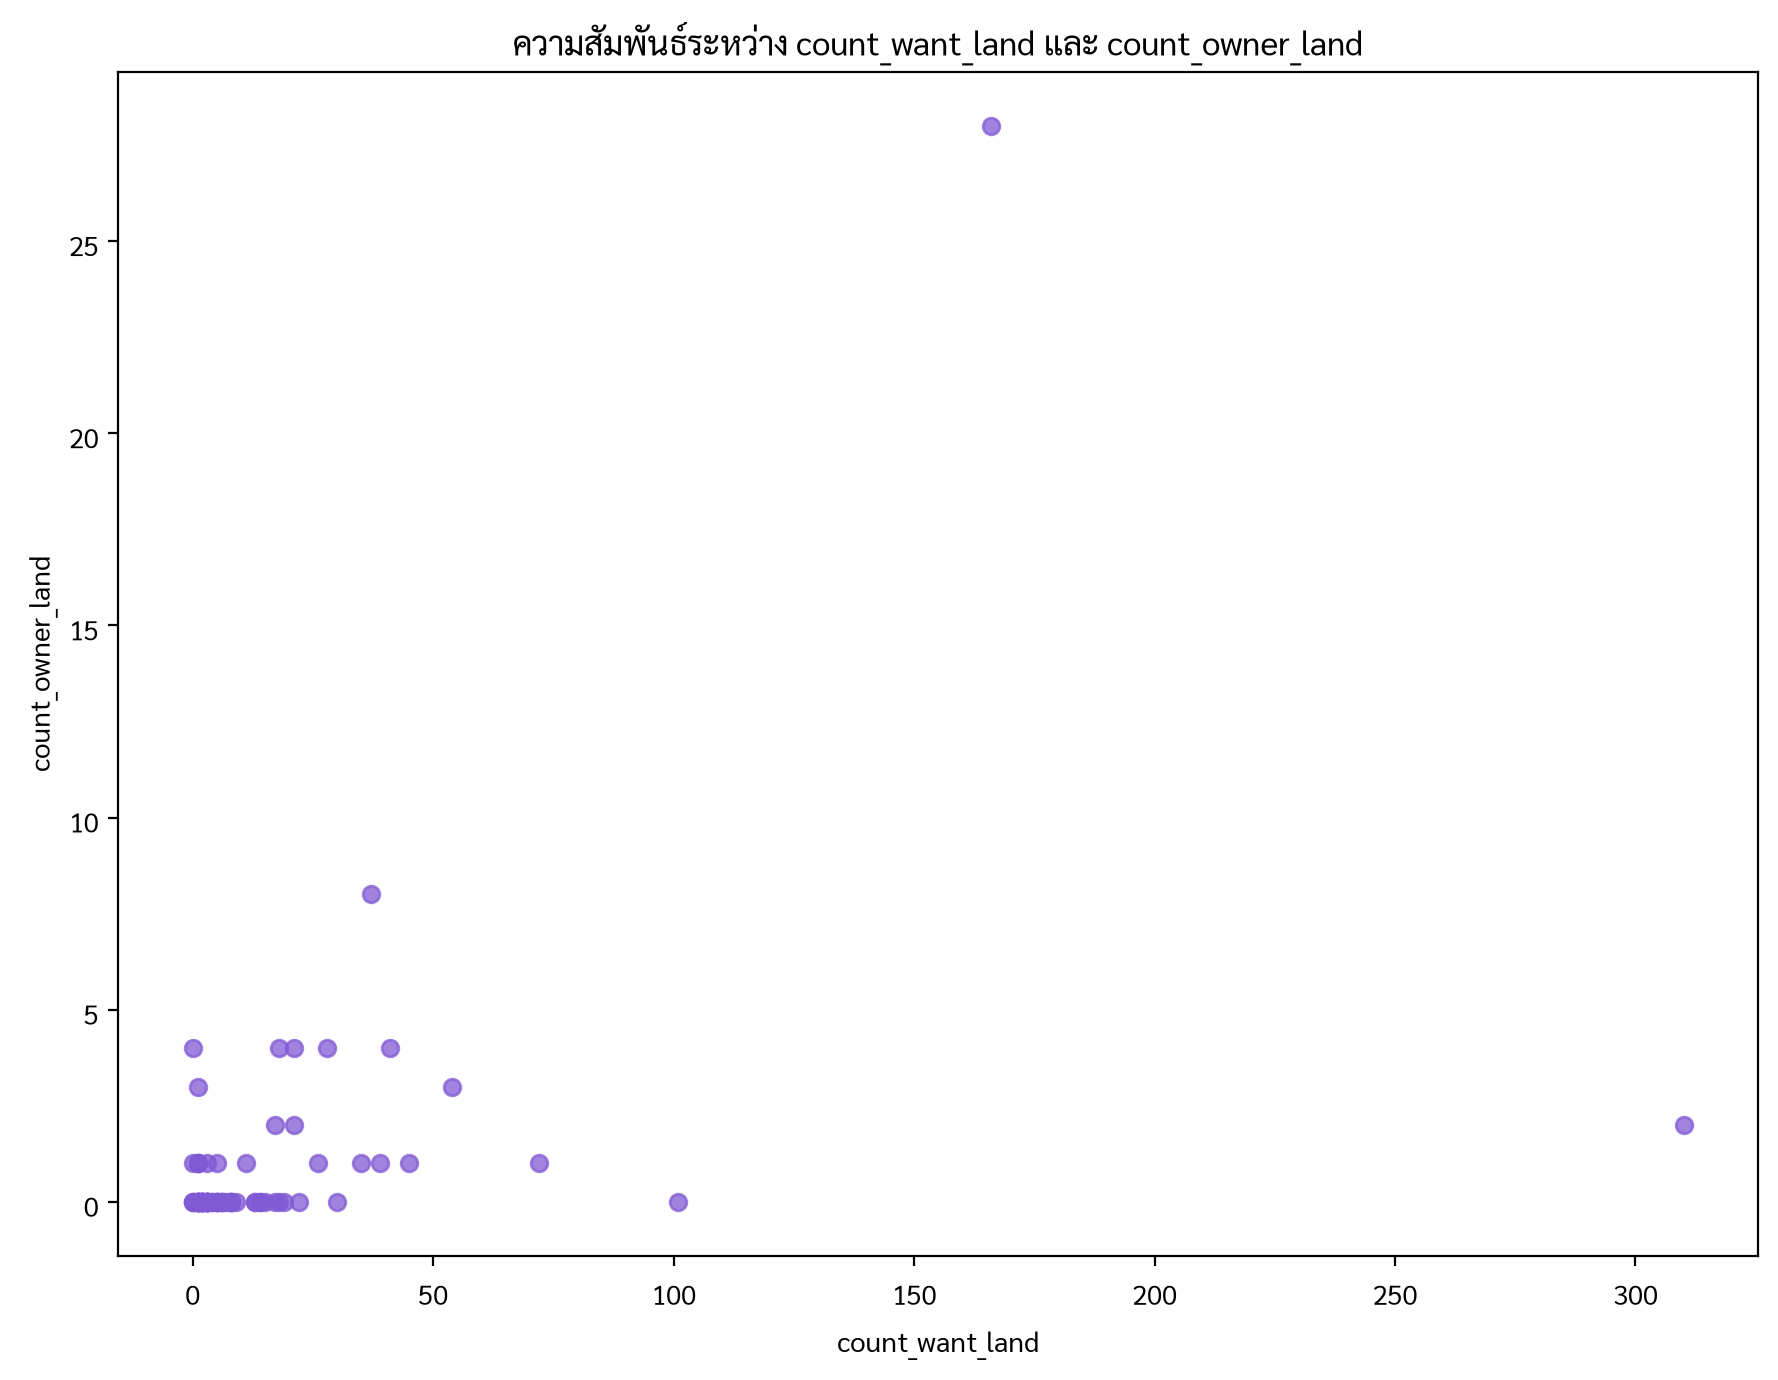

In [31]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(
    province_demand_supply_df[WANT_COUNT_COLUMN],
    province_demand_supply_df[OWNER_LAND_COUNT_COLUMN],
    color="#805ad5",
    alpha=0.75,
)
ax.set_title("ความสัมพันธ์ระหว่าง count_want_land และ count_owner_land")
ax.set_xlabel("count_want_land")
ax.set_ylabel("count_owner_land")
fig.tight_layout()
show_figure(fig)

## แยกแถวการจับคู่ที่มีค่าตัวเลข

column การจับคู่มี `-` จำนวนมาก จึงใช้เฉพาะแถวที่ `จับคู่ได้_numeric` มีค่า
การไม่ปรากฏในตารางนี้ไม่ได้หมายความว่าจังหวัดนั้นมีค่าเป็นศูนย์

In [32]:
matching_observed_df = matching_cleaned_df.dropna(subset=[f"{MATCHED_COUNT_COLUMN}_numeric"])
matching_observed_df[
    [
        PROVINCE_COLUMN,
        f"{MATCHED_COUNT_COLUMN}_numeric",
        f"{APPLICANT_COUNT_COLUMN}_numeric",
        f"{MATCHING_OWNER_COUNT_COLUMN}_numeric",
        f"{LAND_PLOT_COUNT_COLUMN}_numeric",
    ]
]

,province_name,จับคู่ได้_numeric,ผู้ประสงค์_numeric,เจ้าของที่ดิน_numeric,แปลงที่ดิน_numeric
0,กรุงเทพมหานคร,1,1,1,1
3,ปทุมธานี,1,1,1,1
7,สิงห์บุรี,1,1,1,1
16,นครนายก,1,3,1,1
37,เชียงใหม่,2,2,2,2
44,เชียงราย,1,11,1,1
57,นครปฐม,2,3,2,2


## กราฟเปรียบเทียบค่าที่บันทึกในข้อมูลการจับคู่

แหล่งข้อมูลคือ XLSX การจับคู่ ใช้ 4 column ที่แปลงเป็นตัวเลขได้ใน 7 จังหวัด
กราฟตอบคำถามว่าค่าที่บันทึกในแต่ละ column เปรียบเทียบกันอย่างไรเฉพาะแถวที่มีตัวเลข
ไม่ใช้ chart นี้คำนวณอัตราการจับคู่ เพราะ `-` ยังไม่มีนิยามที่ยืนยันได้

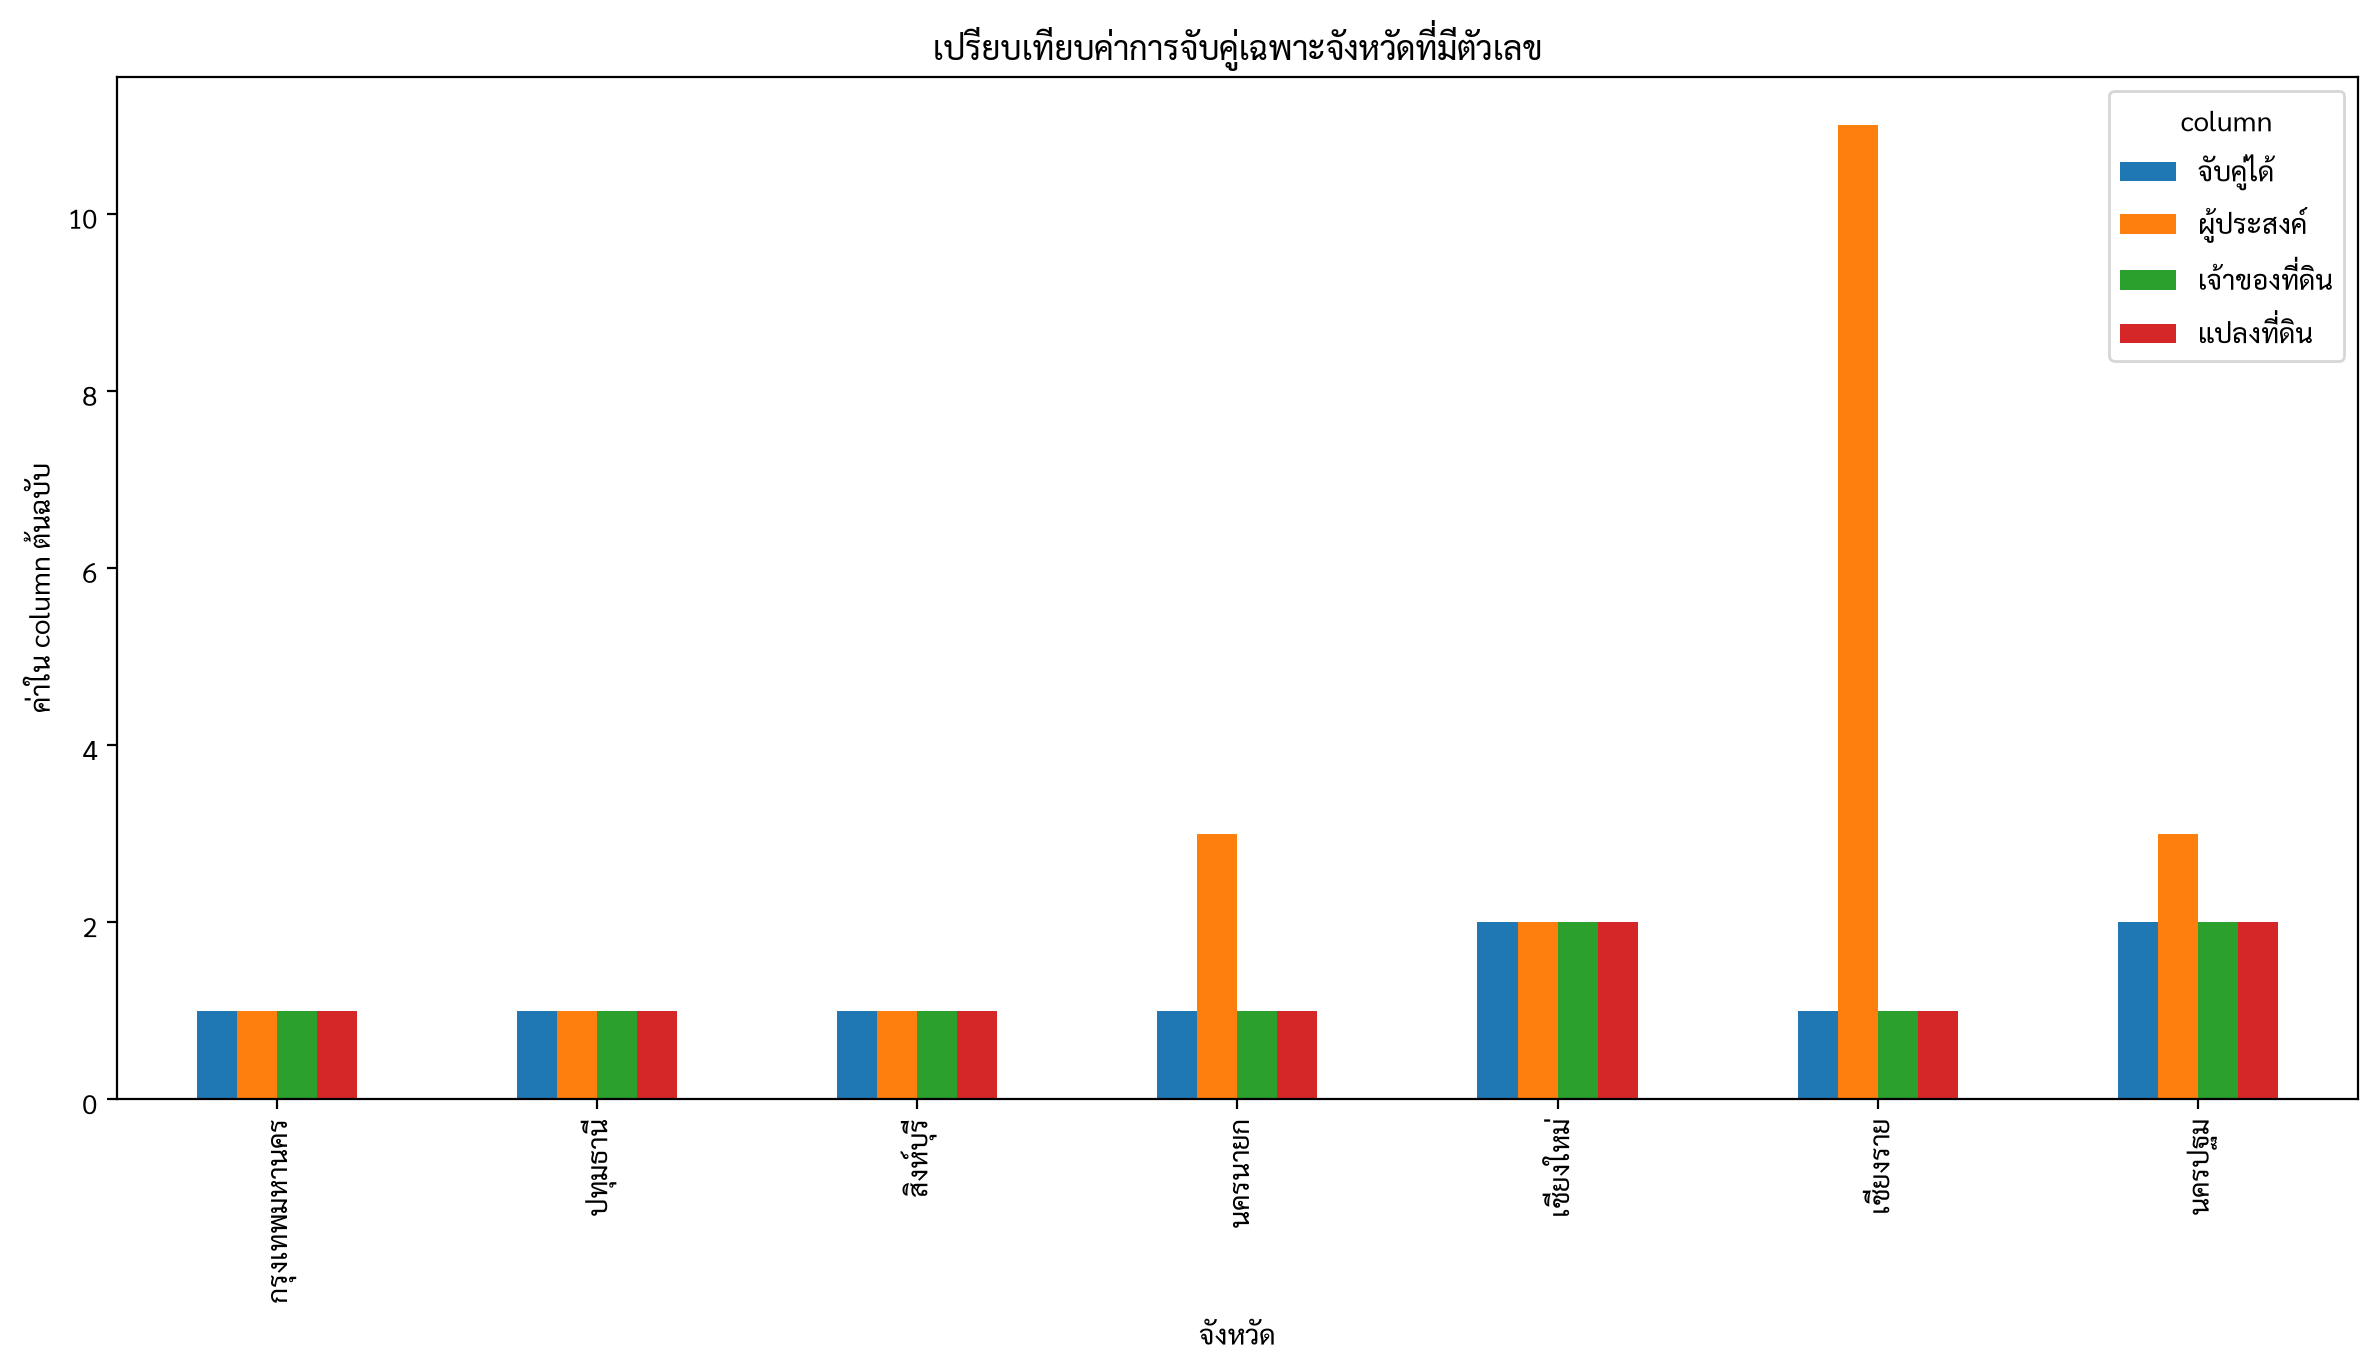

In [33]:
matching_chart_df = matching_observed_df.set_index(PROVINCE_COLUMN)[
    [
        f"{MATCHED_COUNT_COLUMN}_numeric",
        f"{APPLICANT_COUNT_COLUMN}_numeric",
        f"{MATCHING_OWNER_COUNT_COLUMN}_numeric",
        f"{LAND_PLOT_COUNT_COLUMN}_numeric",
    ]
]
matching_chart_df.columns = ["จับคู่ได้", "ผู้ประสงค์", "เจ้าของที่ดิน", "แปลงที่ดิน"]

fig, ax = plt.subplots(figsize=(12, 7))
matching_chart_df.plot(kind="bar", ax=ax)
ax.set_title("เปรียบเทียบค่าการจับคู่เฉพาะจังหวัดที่มีตัวเลข")
ax.set_xlabel("จังหวัด")
ax.set_ylabel("ค่าใน column ต้นฉบับ")
ax.legend(title="column")
fig.tight_layout()
show_figure(fig)

## เปรียบเทียบข้อมูลเจ้าของที่ดินสองไฟล์

cell นี้เชื่อมข้อมูลด้วย `province_name` เพื่อตรวจว่าค่า `count_owner_land` ในสองไฟล์ตรงกันหรือไม่
การเปรียบเทียบเป็นการตรวจความสอดคล้องของไฟล์ที่ดาวน์โหลดในรอบเดียวกัน ไม่ใช่การยืนยันความถูกต้องของข้อมูลต้นทาง

In [34]:
owner_count_comparison_df = demand_supply_cleaned_df[
    [PROVINCE_COLUMN, OWNER_LAND_COUNT_COLUMN]
].merge(
    landowners_cleaned_df[[PROVINCE_COLUMN, "count_owner_land"]],
    on=PROVINCE_COLUMN,
    how="inner",
    suffixes=("_demand_supply", "_landowners"),
)
owner_count_comparison_df["count_owner_land_equal"] = (
    owner_count_comparison_df["count_owner_land_demand_supply"]
    == owner_count_comparison_df["count_owner_land_landowners"]
)
owner_count_comparison_df.head()

,province_name,count_owner_land_demand_supply,count_owner_land_landowners,count_owner_land_equal
0,กรุงเทพมหานคร,1,1,True
1,สมุทรปราการ,0,0,True
2,นนทบุรี,0,0,True
3,ปทุมธานี,1,1,True
4,พระนครศรีอยุธยา,0,0,True


## สรุปความสอดคล้องของข้อมูลเจ้าของที่ดิน

ตารางนี้รายงานจำนวนจังหวัดที่เชื่อมได้และจำนวนจังหวัดที่ค่าของ `count_owner_land` ตรงกัน

In [35]:
owner_count_consistency_df = pd.DataFrame(
    [
        {
            "joined_province_count": owner_count_comparison_df.shape[0],
            "equal_count_owner_land_count": int(
                owner_count_comparison_df["count_owner_land_equal"].sum()
            ),
        }
    ]
)
owner_count_consistency_df

,joined_province_count,equal_count_owner_land_count
0,77,77


## แหล่งข้อมูลและข้อจำกัด

แหล่งข้อมูลอยู่ใน `docs/data-sources.md` และผลการทำความสะอาดอยู่ใน `data/processed/`
ห้ามใช้ผลของ notebook นี้สร้างข้อสรุปเชิงเหตุและผล หรือแทน `-` ด้วยศูนย์ จนกว่าจะได้คำอธิบายจาก metadata หรือหน่วยงานเจ้าของข้อมูล